In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pyfar as pf
import torch
import scipy
import scienceplots
plt.style.use(['science','no-latex'])
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [2]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=10,
    num_obs_times_per_rev=100,
    device='cuda'
)

In [3]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
    dtype=torch.float32
)

propeller.run_bemt(v_inf=0.0)

In [4]:
r_observers = 1.88 * np.array([
    [0.050,  0.000, -0.999], # Position 1
    [0.150, -0.856,  0.494], # Position 2
    [0.250,  0.839,  0.484], # Position 3
    [0.350,  0.811, -0.468], # Position 4
    [0.450, -0.773, -0.447], # Position 5
    [0.550,  0.000,  0.835], # Position 6
    [0.650,  0.658,  0.380], # Position 7
    [0.750,  0.000, -0.661], # Position 8
    [0.850, -0.456,  0.263], # Position 9
    [0.950,  0.000,  0.312]  # Position 10
])

In [17]:
propeller.run_aeroacoustics(observer_positions=r_observers,
        lt=0.1,
        i=2e-3,
        alpha_stall=12.5,
        keep_bpm_components=False)

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 3.044 ms
[CUDA TIMING] BPM.__init__: 1.604 ms
[CUDA TIMING] get_observer_times: 0.565 ms
[CUDA TIMING] calculate_f1a_pressure: 4.980 ms
[CUDA TIMING] combine_sources (F1A): 1.087 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 4.826 ms
[CUDA TIMING] BPM.run_forward_bpm: 26.804 ms
[CUDA TIMING] combine_sources_bpm: 0.641 ms


In [18]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency tensor f."""
       
    # Helper for the Ra calculation
    def ra_calc(freq):
        # Using ** 0.5 works for both Tensors and floats/ints
        return (12194**2 * freq**4) / (
            (freq**2 + 20.6**2) * ((freq**2 + 107.7**2) * (freq**2 + 737.9**2))**0.5 * (freq**2 + 12194**2)
        )

    ra = ra_calc(f)
    ra_1000 = ra_calc(1000.0)
    
    return 20 * torch.log10(ra) - 20 * torch.log10(torch.tensor(ra_1000))

def calc_oaspl(spl_tensor, freqs, weighted=False):
    """
    Calculates OASPL for an arbitrary grid shape.
    spl_tensor: (F, ...) where F is the number of frequency bins
    freqs: (F,)
    """
    # 1. Handle Weighting
    if weighted:
        a_offsets = get_a_weighting(freqs).to(spl_tensor.device)
        
        # Reshape (F,) to (F, 1, 1, ..., 1) to match spl_tensor's rank
        # Use None/unsqueeze or view to align the frequency dimension
        dims_to_add = spl_tensor.ndim - 1
        view_shape = (-1,) + (1,) * dims_to_add
        
        spl_tensor = spl_tensor + a_offsets.view(view_shape)
        
    # 2. Convert SPL to linear power ratio
    # Formula: 10^(SPL/10)
    power_ratio = 10**(spl_tensor / 10)
    
    # 3. Logarithmic Summation
    # Sum across the first dimension (frequency)
    summed_power = torch.sum(power_ratio, dim=0)
    
    # Formula: 10 * log10(sum(10^(SPL_i / 10)))
    return 10 * torch.log10(summed_power)

In [19]:
f_low = propeller.third_octave_freqs / (2 ** (1 / 6))
f_high = propeller.third_octave_freqs * (2 ** (1 / 6))
freqs = propeller.freq[:, 0]
mask = (propeller.freq[:, 0:1].T >= f_low.unsqueeze(1)) & \
       (propeller.freq[:, 0:1].T < f_high.unsqueeze(1))

# 4. Convert SPL to Power
p_raw = 10 ** (propeller.spl / 10)
p_band = torch.matmul(mask.float(), p_raw)
f1a_spl_3oct = 10 * torch.log10(p_band.clamp(min=1e-12))
f1a_spl_3oct[p_band == 0] = float('-inf')

In [20]:
L_total = 10 * torch.log10(
    10 ** (f1a_spl_3oct / 10)
    + 10 ** (propeller.spl_total / 10)
)

In [21]:
OASPL_values = calc_oaspl(L_total, propeller.third_octave_freqs, weighted=True).cpu().numpy()

In [22]:
def load_data(filepath, channel):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels'][str(channel)]['time']
    p = data['sound']['channels'][str(channel)]['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs


def extract_propeller_noise(p_total, p_motor, fs, nperseg=1024, alpha=1.0, beta=0.1):
    f, t, Zxx_total = scipy.signal.stft(p_total, fs=fs, nperseg=nperseg)
    _, _, Zxx_motor = scipy.signal.stft(p_motor, fs=fs, nperseg=nperseg)

    mag_total = np.abs(Zxx_total)
    phase_total = np.angle(Zxx_total)
    mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

    mag_prop = np.maximum(mag_total - (alpha * mag_motor_avg), beta * mag_motor_avg)
    
    Zxx_prop = mag_prop * np.exp(1j * phase_total)
    t_final, p_prop_only = scipy.signal.istft(Zxx_prop, fs=fs)
    
    return t_final, p_prop_only

In [23]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [24]:
def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

In [25]:
third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(
    num_fractions=3, frequency_range=(20, 20000)
)[0]

In [26]:
# res = []

# f_low = third_octave_freqs / (2 ** (1 / 6))
# f_high = third_octave_freqs * (2 ** (1 / 6))

# for channel in range(1,11):
#     t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl', channel=channel)
#     t_motor, p_motor, fs_motor = load_data('../Datasets/Background/Background_2024-11-28-12-56-35_RPM_7000.pkl', channel=channel)
#     t_final, p_prop_only = extract_propeller_noise(p_total, p_motor, fs_total)
#     fs = 1 / (t_final[1] - t_final[0])
#     signal = pf.Signal(p_prop_only, fs, fft_norm='rms')
#     clean_frequencies = signal.frequencies[np.newaxis, ...]
#     clean_spl = pf.dsp.decibel(signal, domain='freq', log_reference=2e-5).T

#     mask = (clean_frequencies >= f_low[..., np.newaxis]) & \
#         (clean_frequencies <= f_high[..., np.newaxis])

#     # 4. Convert SPL to Power
#     p_raw = 10 ** (clean_spl / 10)
#     p_band = mask @ p_raw
#     clean_spl_3oct = 10 * np.log10(p_band)
#     clean_spl_3oct[p_band == 0] = -np.inf
#     clean_ospl_exp = calc_oaspl(clean_spl_3oct.squeeze(), third_octave_freqs, weighted=True)
#     res.append(clean_ospl_exp)


In [27]:
X = r_observers[:, 0]
Y = (r_observers[:, 1]**2 + r_observers[:, 2]**2)**0.5

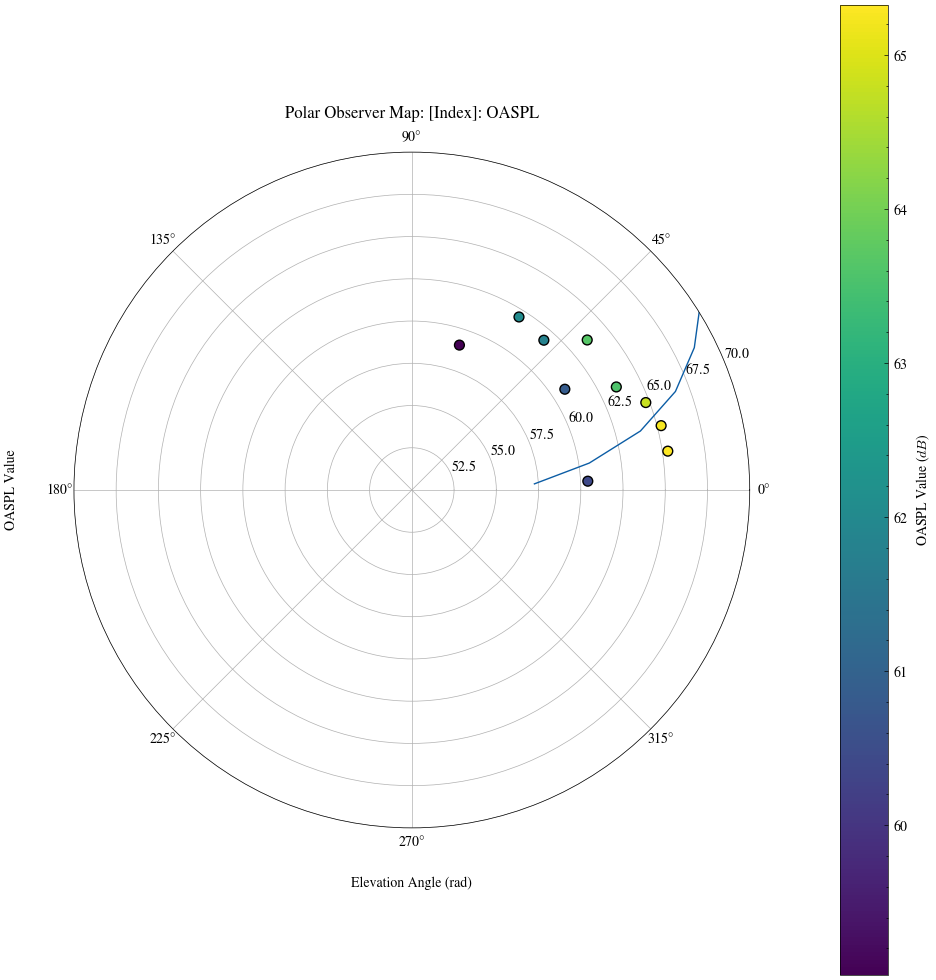

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming X, Y, and res are already defined as numpy arrays or lists
# X: Height above propeller plane
# Y: Distance from propeller axis
# res: OASPL values

# 1. Calculate the elevation angle (in radians)
# np.arctan2(y, x) -> in our case arctan2(Height, Distance)
theta = np.arctan2(X, Y)

# 2. Set the radius as the OASPL value
r = res

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

# Create the scatter plot on the polar axes
# cmap='viridis' is kept for consistency
sc = ax.scatter(theta, r, c=res, cmap='viridis', s=50, edgecolors='black', zorder=3)

# Add colorbar
plt.colorbar(sc, ax=ax, label='OASPL Value ($dB$)', pad=0.1)

# Add labels (Index: Value) to each point
# for i, val in enumerate(res):
#     label_text = f'${i+1}$' 
#     ax.annotate(
#         label_text, 
#         (theta[i], r[i]), 
#         textcoords="offset points", 
#         xytext=(5, 5), 
#         fontsize=8,
#         fontweight='bold',
#         alpha=0.8
#     )

ax.plot(theta, OASPL_values)

# Optional: Configure the polar grid
ax.set_theta_zero_location('E') # Sets 0 degrees to the Right (Positive Y-axis)
ax.set_theta_direction(1)       # Counter-clockwise
ax.set_xlabel('Elevation Angle (rad)', labelpad=20)
ax.set_ylabel('OASPL Value', labelpad=40)
ax.set_title('Polar Observer Map: [Index]: OASPL', va='bottom')
ax.set_rlim(50,70)
plt.tight_layout()
plt.savefig('polar_observer_map.png')
plt.show()